In [1]:
import pandas as pd

CSV_URL = 'https://dpl6hyzg28thp.cloudfront.net/media/full_economic_data.csv'

try:
    full_data = pd.read_csv(CSV_URL, parse_dates=['DATE'], index_col='DATE')
except Exception:
    full_data = pd.read_csv('full_economic_data.csv', parse_dates=['DATE'], index_col='DATE')

full_data = full_data.asfreq('QS')
full_data = full_data.dropna()

print(len(full_data), "quarterly observations from",
      full_data.index[0].date(), "to", full_data.index[-1].date())
full_data.head()

189 quarterly observations from 1978-01-01 to 2025-01-01


,UNRATE,CIVPART,CPIAUCSL,FEDFUNDS,GDPC1,UMCSENT,FEDMINNFRWG,PAYEMS,PCE,DSPIC96,NETEXP,M2SL
DATE,,,,,,,,,,,,
1978-01-01,6.4,62.8,62.7,6.70,6796.260,83.7,2.65,84594.0,1329.5,4962.0,-38.681,1279.7
1978-04-01,6.1,63.0,63.9,6.89,7058.920,81.6,2.65,86162.0,1396.4,5050.5,-22.624,1300.4
1978-07-01,6.2,63.2,65.5,7.81,7129.915,82.4,2.65,87204.0,1426.8,5072.8,-23.760,1324.1
1978-10-01,5.8,63.3,67.1,8.96,7225.750,79.3,2.65,87956.0,1466.9,5109.5,-16.400,1352.3
1979-01-01,5.9,63.6,68.5,10.07,7238.727,72.1,2.90,88808.0,1502.4,5164.0,-18.159,1371.6


In [2]:
mw = full_data['FEDMINNFRWG']
n_changes = (mw.diff().fillna(0) != 0).sum()

print("distinct values:", mw.nunique())
print("number of changes:", n_changes)
print("values:", sorted(mw.unique()))
print("last change:", mw.index[(mw.diff().fillna(0) != 0)][-1].date())

distinct values: 11
number of changes: 10
values: [np.float64(2.65), np.float64(2.9), np.float64(3.1), np.float64(3.35), np.float64(3.8), np.float64(4.25), np.float64(4.75), np.float64(5.15), np.float64(5.85), np.float64(6.55), np.float64(7.25)]
last change: 2009-07-01


In [3]:
from sklearn.preprocessing import StandardScaler

y = full_data['GDPC1']
exog = full_data.drop(columns='GDPC1')

scaler = StandardScaler()
exog_scaled = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns, index=exog.index)

split_idx = int(len(full_data) * 0.8)

y_train, y_test = y[:split_idx], y[split_idx:]
exog_train, exog_test = exog_scaled[:split_idx], exog_scaled[split_idx:]

print("train:", len(y_train), "quarters,", y_train.index[0].date(), "to", y_train.index[-1].date())
print("test: ", len(y_test), "quarters,", y_test.index[0].date(), "to", y_test.index[-1].date())

train: 151 quarters, 1978-01-01 to 2015-07-01
test:  38 quarters, 2015-10-01 to 2025-01-01


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

exog_vars_ctl = ['CIVPART', 'CPIAUCSL', 'UMCSENT', 'PAYEMS', 'PCE']
exog_vars_exp = exog_vars_ctl + ['FEDMINNFRWG']

def init_model(exog_vars):
    return SARIMAX(
        y_train,
        exog=exog_train[exog_vars],
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

results_ctl = init_model(exog_vars_ctl).fit(method='powell', maxiter=1000, disp=False)
results_exp = init_model(exog_vars_exp).fit(method='powell', maxiter=1000, disp=False)

print("SARIMAX AIC without minimum wage:", round(results_ctl.aic, 1))
print("SARIMAX AIC with minimum wage:   ", round(results_exp.aic, 1))
print("difference:", round(results_exp.aic - results_ctl.aic, 2))
print("parameters:", len(results_ctl.params), "without,", len(results_exp.params), "with")

SARIMAX AIC without minimum wage: 1657.0
SARIMAX AIC with minimum wage:    1658.6
difference: 1.58
parameters: 8 without, 9 with


In [5]:
from scipy import stats

coef = results_exp.params['FEDMINNFRWG']
z = results_exp.zvalues['FEDMINNFRWG']
p = results_exp.pvalues['FEDMINNFRWG']
print(f"minimum wage coefficient = {coef:.3f},  z = {z:.2f},  p = {p:.2f}")

LR_stat = 2 * (results_exp.llf - results_ctl.llf)
p_value = stats.chi2.sf(LR_stat, 1)
print(f"likelihood ratio statistic = {LR_stat:.2f},  p = {p_value:.2f}")

minimum wage coefficient = 47.314,  z = 0.49,  p = 0.62
likelihood ratio statistic = 0.42,  p = 0.52


In [6]:
import statsmodels.formula.api as smf

data_for_lm = pd.DataFrame(
    {"previous_GDP": y_train.values[:-1], "current_GDP": y_train.values[1:]},
    index=y_train.index[1:]
)
for v in exog_vars_exp:
    data_for_lm[v] = exog_train[v].values[1:]

depvar = 'current_GDP'
mod1 = smf.ols(depvar + ' ~ previous_GDP + ' + ' + '.join(exog_vars_ctl), data=data_for_lm).fit()
mod2 = smf.ols(depvar + ' ~ previous_GDP + ' + ' + '.join(exog_vars_exp), data=data_for_lm).fit()

print("linear AIC without minimum wage:", round(mod1.aic, 1))
print("linear AIC with minimum wage:   ", round(mod2.aic, 1))
print("difference:", round(mod2.aic - mod1.aic, 2))
print("coefficients:", int(mod1.df_model) + 1, "without,", int(mod2.df_model) + 1, "with")

t = mod2.tvalues['FEDMINNFRWG']
p = mod2.pvalues['FEDMINNFRWG']
print(f"\nminimum wage coefficient = {mod2.params['FEDMINNFRWG']:.3f},  t = {t:.2f},  p = {p:.2f}")

LR_stat = 2 * (mod2.llf - mod1.llf)
p_value = stats.chi2.sf(LR_stat, 1)
print(f"likelihood ratio statistic = {LR_stat:.2f},  p = {p_value:.2f}")

linear AIC without minimum wage: 1728.3
linear AIC with minimum wage:    1729.9
difference: 1.58
coefficients: 7 without, 8 with

minimum wage coefficient = 20.862,  t = 0.63,  p = 0.53
likelihood ratio statistic = 0.42,  p = 0.52


In [7]:
import numpy as np

fc_ctl = results_ctl.get_forecast(len(y_test), exog=exog_test[exog_vars_ctl])
fc_exp = results_exp.get_forecast(len(y_test), exog=exog_test[exog_vars_exp])
sar_ctl = fc_ctl.predicted_mean
sar_exp = fc_exp.predicted_mean
ci = fc_ctl.conf_int()

def linear_forecast(mod, exog_vars):
    prev = y_train.values[-1]
    preds = []
    for i in range(len(y_test)):
        row = {'previous_GDP': prev}
        for v in exog_vars:
            row[v] = exog_test[v].values[i]
        pred = float(mod.predict(pd.DataFrame([row])).iloc[0])
        preds.append(pred)
        prev = pred
    return pd.Series(preds, index=y_test.index)

lin_ctl = linear_forecast(mod1, exog_vars_ctl)
lin_exp = linear_forecast(mod2, exog_vars_exp)

print("forecasts generated for", len(y_test), "quarters")

forecasts generated for 38 quarters


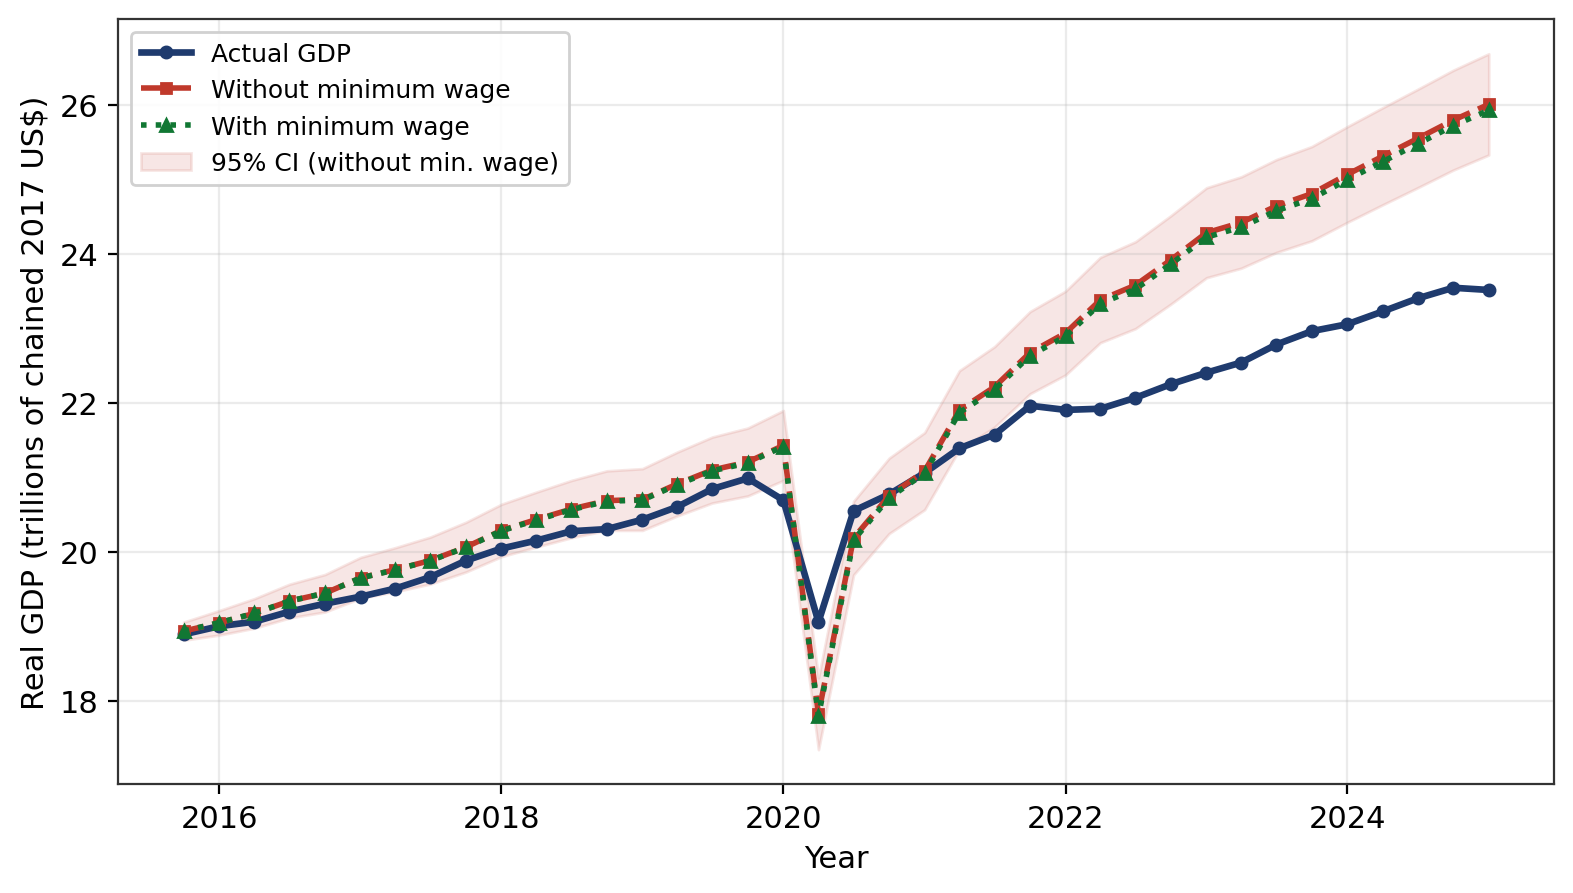

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans',
                     'figure.dpi': 200, 'savefig.dpi': 200, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.edgecolor': '#333333'})

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(y_test.index, y_test / 1000, color='#1f3b6e', lw=2.4, marker='o', ms=4,
        label='Actual GDP')
ax.plot(y_test.index, sar_ctl / 1000, color='#c0392b', lw=2.0, ls='--', marker='s', ms=3.5,
        label='Without minimum wage')
ax.plot(y_test.index, sar_exp / 1000, color='#117733', lw=2.0, ls=':', marker='^', ms=4,
        label='With minimum wage')
ax.fill_between(y_test.index, ci.iloc[:, 0] / 1000, ci.iloc[:, 1] / 1000,
                color='#c0392b', alpha=0.12, label='95% CI (without min. wage)')
ax.set_xlabel('Year')
ax.set_ylabel('Real GDP (trillions of chained 2017 US$)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=True, framealpha=0.9, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('fig1_sarimax.png', bbox_inches='tight')
plt.show()

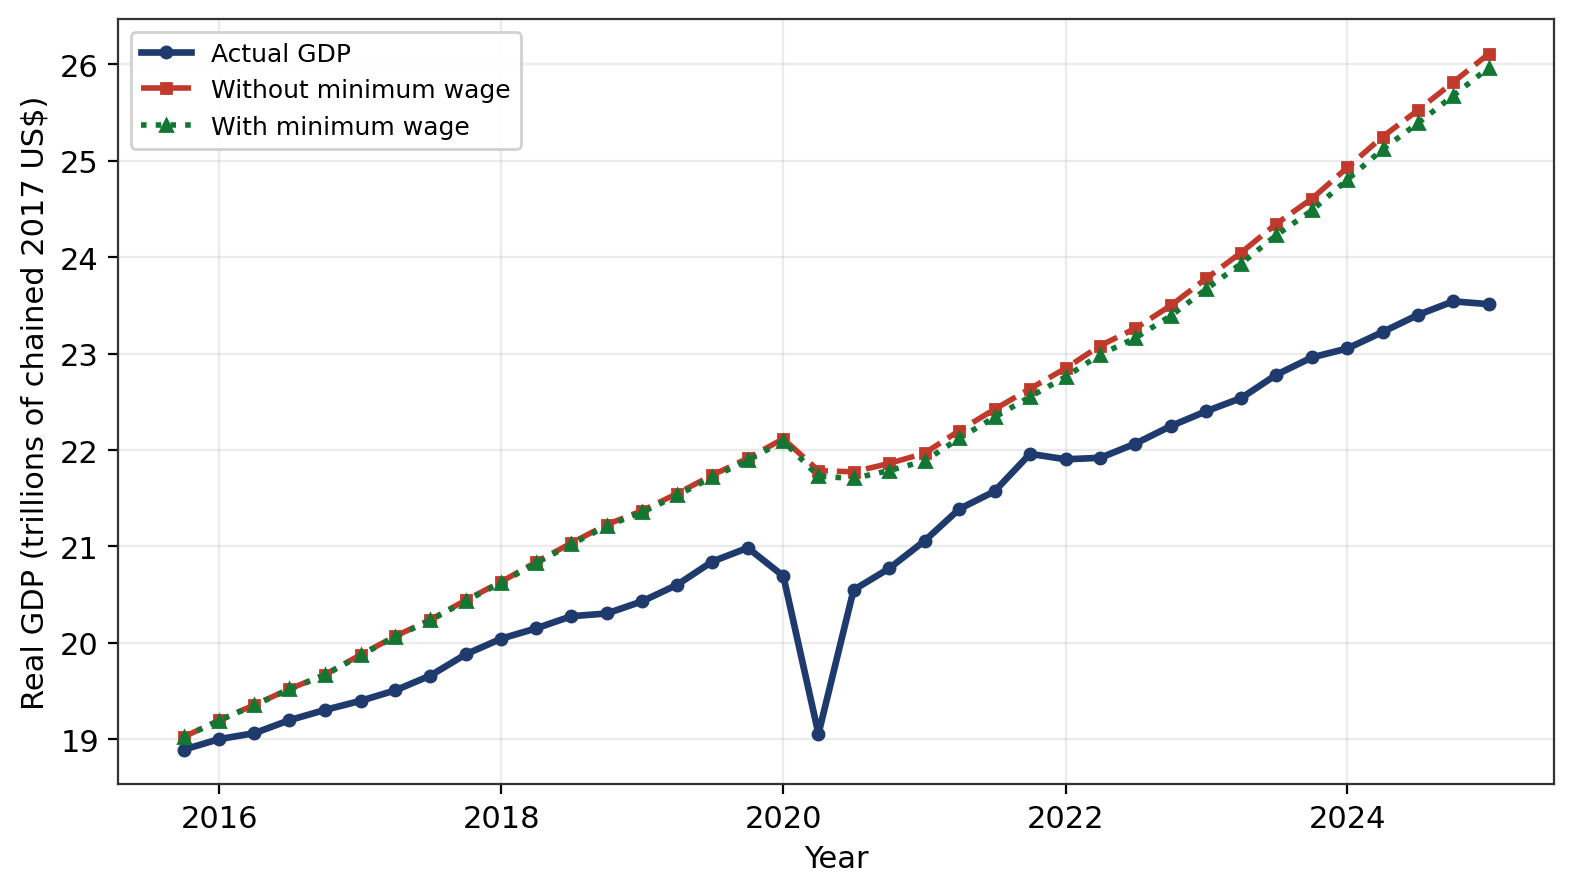

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(y_test.index, y_test / 1000, color='#1f3b6e', lw=2.4, marker='o', ms=4,
        label='Actual GDP')
ax.plot(y_test.index, lin_ctl / 1000, color='#c0392b', lw=2.0, ls='--', marker='s', ms=3.5,
        label='Without minimum wage')
ax.plot(y_test.index, lin_exp / 1000, color='#117733', lw=2.0, ls=':', marker='^', ms=4,
        label='With minimum wage')
ax.set_xlabel('Year')
ax.set_ylabel('Real GDP (trillions of chained 2017 US$)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=True, framealpha=0.9, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('fig2_linear.png', bbox_inches='tight')
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def errors(name, forecast):
    mse = mean_squared_error(y_test, forecast)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100
    return {'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAPE (%)': mape}

table2 = pd.DataFrame([
    errors('Linear, without minimum wage', lin_ctl),
    errors('Linear, with minimum wage', lin_exp),
    errors('SARIMAX, without minimum wage', sar_ctl),
    errors('SARIMAX, with minimum wage', sar_exp),
])
table2['MSE'] = table2['MSE'].map(lambda v: f"{v/1e6:.2f} x 10^6")
table2['RMSE'] = table2['RMSE'].round(0).astype(int)
table2['MAPE (%)'] = table2['MAPE (%)'].round(2)
table2

,Model,MSE,RMSE,MAPE (%)
0,"Linear, without minimum wage",1.60 x 10^6,1264,5.06
1,"Linear, with minimum wage",1.43 x 10^6,1194,4.79
2,"SARIMAX, without minimum wage",1.33 x 10^6,1155,3.80
3,"SARIMAX, with minimum wage",1.25 x 10^6,1118,3.69


In [11]:
import itertools

optional_vars = [v for v in exog.columns if v != 'FEDMINNFRWG']

rows = []
for r in range(len(optional_vars) + 1):
    for subset in itertools.combinations(optional_vars, r):
        for with_mw in (False, True):
            vars_ = (['FEDMINNFRWG'] if with_mw else []) + list(subset)
            try:
                if vars_:
                    model = SARIMAX(y_train, exog=exog_train[vars_], order=(1, 1, 1),
                                    enforce_stationarity=False, enforce_invertibility=False)
                else:
                    model = SARIMAX(y_train, order=(1, 1, 1),
                                    enforce_stationarity=False, enforce_invertibility=False)
                res = model.fit(method='powell', maxiter=1000, disp=False)
                rows.append((with_mw, '|'.join(subset), res.aic))
            except Exception:
                rows.append((with_mw, '|'.join(subset), np.nan))

search = pd.DataFrame(rows, columns=['with_mw', 'controls', 'aic']).dropna(subset=['aic'])
print(len(search), "models fit")

best = search.loc[search['aic'].idxmin()]
print("lowest AIC:", round(best['aic'], 2))
print("achieved by:", best['controls'].split('|'), "| minimum wage included:", bool(best['with_mw']))

2048 models fit
lowest AIC: 1657.0
achieved by: ['CIVPART', 'CPIAUCSL', 'UMCSENT', 'PAYEMS', 'PCE'] | minimum wage included: False


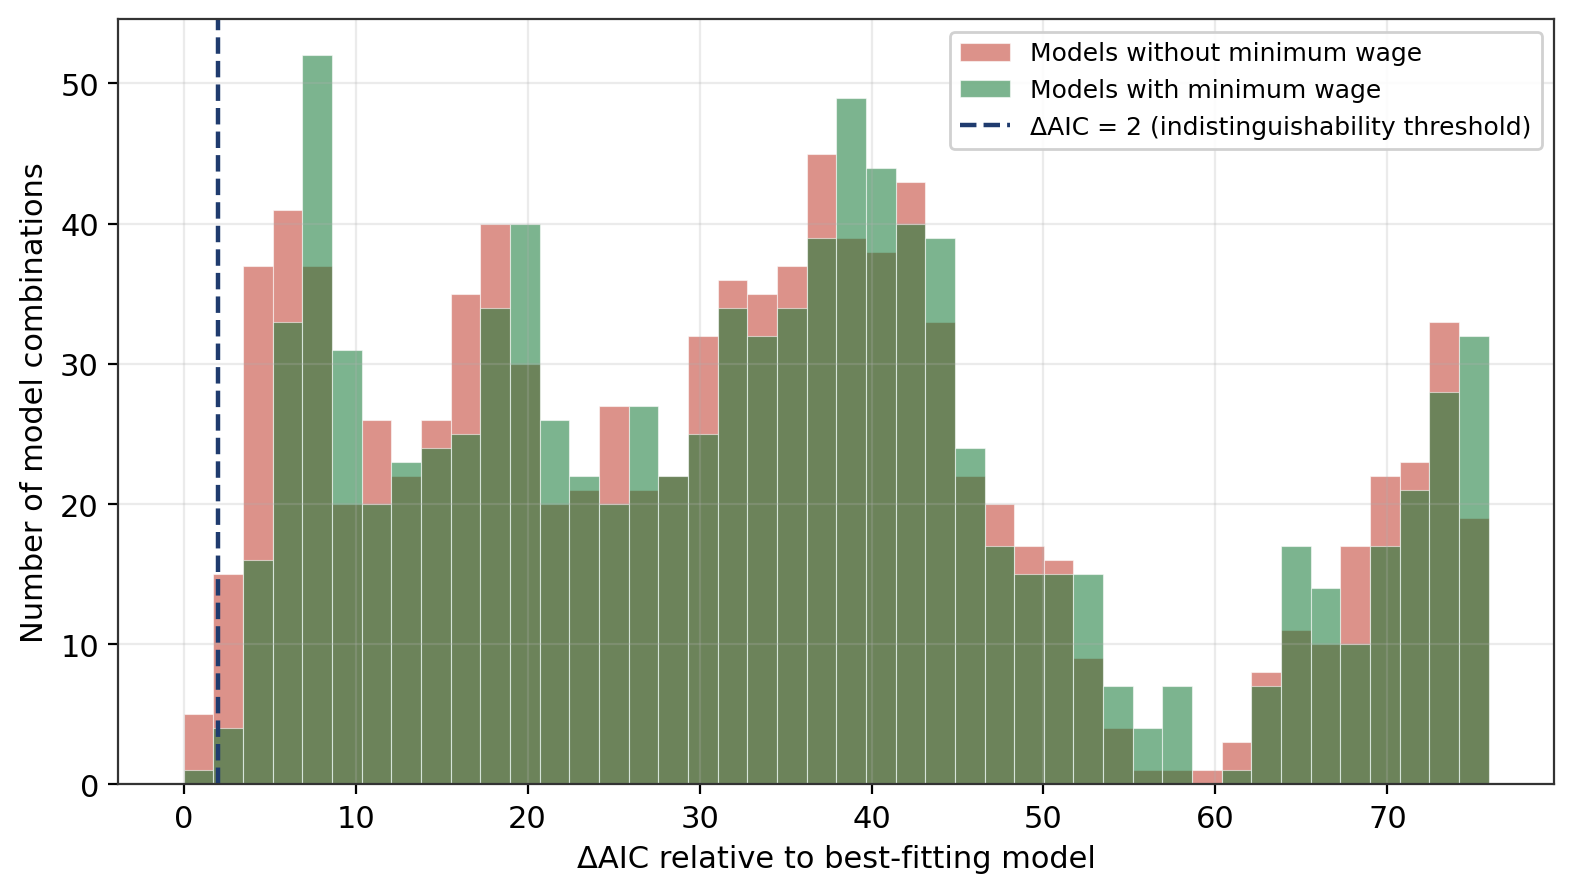

In [12]:
search['dAIC'] = search['aic'] - search['aic'].min()

fig, ax = plt.subplots(figsize=(8, 4.6))
bins = np.linspace(0, min(search['dAIC'].quantile(0.99), search['dAIC'].max()), 45)
ax.hist(search.loc[~search['with_mw'], 'dAIC'], bins=bins, color='#c0392b', alpha=0.55,
        label='Models without minimum wage', edgecolor='white', linewidth=0.4)
ax.hist(search.loc[search['with_mw'], 'dAIC'], bins=bins, color='#117733', alpha=0.55,
        label='Models with minimum wage', edgecolor='white', linewidth=0.4)
ax.axvline(2, color='#1f3b6e', ls='--', lw=1.6,
           label='\u0394AIC = 2 (indistinguishability threshold)')
ax.set_xlabel('\u0394AIC relative to best-fitting model')
ax.set_ylabel('Number of model combinations')
ax.legend(frameon=True, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig('fig3_aic_hist.png', bbox_inches='tight')
plt.show()

In [13]:
pairs = search.pivot_table(index='controls', columns='with_mw', values='aic').dropna()
pairs.columns = ['without_mw', 'with_mw']
pairs['delta'] = pairs['with_mw'] - pairs['without_mw']

n_better = (pairs['delta'] < 0).sum()
print(f"minimum wage lowered the AIC in {n_better} of {len(pairs)} matched pairs "
      f"({100 * n_better / len(pairs):.1f}%)")
print(f"share of pairs differing by less than 2 AIC units: "
      f"{100 * (pairs['delta'].abs() < 2).mean():.1f}%")

minimum wage lowered the AIC in 33 of 1024 matched pairs (3.2%)
share of pairs differing by less than 2 AIC units: 79.9%


In [14]:
full_data.describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
UNRATE,6.07,1.82,3.40,14.80
CIVPART,64.83,1.72,60.10,67.30
CPIAUCSL,179.69,64.62,62.70,319.09
FEDFUNDS,4.66,4.08,0.05,19.08
GDPC1,14166.64,4841.14,6796.26,23542.35
UMCSENT,84.86,13.26,51.50,112.00
FEDMINNFRWG,5.26,1.62,2.65,7.25
PAYEMS,123550.74,20422.34,84594.00,159053.00
PCE,7937.36,5000.76,1329.50,20370.00
DSPIC96,10408.58,3786.27,4962.00,18146.50
